In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## INITIAL DATA EXPLORATION


In [2]:
#loading data
df = pd.read_csv('Master_Global_Budgets_Historical.csv')
df.head(50)


,Country,Year,Defense_Percentage,Education_Percentage,Health_Percentage,Interest_Payments_Percentage,Total_Budget_Billions_USD,Infrastructure_Percentage,Agriculture_Percentage,State_Transfers_Percentage,...,Administration_and_Others_Percentage,Defense_Amount_Billions_USD,Education_Amount_Billions_USD,Health_Amount_Billions_USD,Interest_Payments_Amount_Billions_USD,Infrastructure_Amount_Billions_USD,Agriculture_Amount_Billions_USD,State_Transfers_Amount_Billions_USD,Social_Welfare_Amount_Billions_USD,Administration_and_Others_Amount_Billions_USD
0,Argentina,1946,5.78,15.4,17.82,8.65,1.552,13.09,7.85,10.47,...,10.47,0.090,0.239,0.276,0.134,0.203,0.122,0.162,0.162,0.162
1,Argentina,1947,5.78,15.4,17.82,8.65,1.629,13.09,7.85,10.47,...,10.47,0.094,0.251,0.290,0.141,0.213,0.128,0.171,0.171,0.171
2,Argentina,1948,5.78,15.4,17.82,8.65,1.711,13.09,7.85,10.47,...,10.47,0.099,0.263,0.305,0.148,0.224,0.134,0.179,0.179,0.179
3,Argentina,1949,5.78,15.4,17.82,8.65,1.796,13.09,7.85,10.47,...,10.47,0.104,0.277,0.320,0.155,0.235,0.141,0.188,0.188,0.188
4,Argentina,1950,5.78,15.4,17.82,8.65,1.886,13.09,7.85,10.47,...,10.47,0.109,0.290,0.336,0.163,0.247,0.148,0.197,0.197,0.197
5,Argentina,1951,5.78,15.4,17.82,8.65,1.980,13.09,7.85,10.47,...,10.47,0.114,0.305,0.353,0.171,0.259,0.155,0.207,0.207,0.207
6,Argentina,1952,5.78,15.4,17.82,8.65,2.079,13.09,7.85,10.47,...,10.47,0.120,0.320,0.371,0.180,0.272,0.163,0.218,0.218,0.218
7,Argentina,1953,5.78,15.4,17.82,8.65,2.183,13.09,7.85,10.47,...,10.47,0.126,0.336,0.389,0.189,0.286,0.171,0.229,0.229,0.229
8,Argentina,1954,5.78,15.4,17.82,8.65,2.292,13.09,7.85,10.47,...,10.47,0.132,0.353,0.408,0.198,0.300,0.180,0.240,0.240,0.240
9,Argentina,1955,5.78,15.4,17.82,8.65,2.407,13.09,7.85,10.47,...,10.47,0.139,0.371,0.429,0.208,0.315,0.189,0.252,0.252,0.252


In [3]:
#assessing basic attributes

def assess_data(df):
    print("INITAL DATA ASSESSMENT: ")
    print("\n")
    print(f"shape: {df.shape}")
    print(f"\nnumber of missing values:\n {df.isnull().sum()}")
    print(f"\ndata types:\n {df.dtypes}")
    print(f"\nduplicated rows:\n {df.duplicated()}")
    print(f"\ncolumns present:\n {df.columns}")
    print(f"\ncountries present in the dataset:\n {df['Country'].nunique()}")
    print(f"\nyear range:\n {df['Year'].min()} - {df['Year'].max()}")

assess_data(df)

INITAL DATA ASSESSMENT: 


shape: (3654, 21)

number of missing values:
 Country                                          0
Year                                             0
Defense_Percentage                               0
Education_Percentage                             0
Health_Percentage                                0
Interest_Payments_Percentage                     0
Total_Budget_Billions_USD                        0
Infrastructure_Percentage                        0
Agriculture_Percentage                           0
State_Transfers_Percentage                       0
Social_Welfare_Percentage                        0
Administration_and_Others_Percentage             0
Defense_Amount_Billions_USD                      0
Education_Amount_Billions_USD                    0
Health_Amount_Billions_USD                       0
Interest_Payments_Amount_Billions_USD            0
Infrastructure_Amount_Billions_USD               0
Agriculture_Amount_Billions_USD                  0
State_Tra

## DATA CLEANING

In [4]:
# checking for any missing values: 
df.isnull().sum()

Country                                          0
Year                                             0
Defense_Percentage                               0
Education_Percentage                             0
Health_Percentage                                0
Interest_Payments_Percentage                     0
Total_Budget_Billions_USD                        0
Infrastructure_Percentage                        0
Agriculture_Percentage                           0
State_Transfers_Percentage                       0
Social_Welfare_Percentage                        0
Administration_and_Others_Percentage             0
Defense_Amount_Billions_USD                      0
Education_Amount_Billions_USD                    0
Health_Amount_Billions_USD                       0
Interest_Payments_Amount_Billions_USD            0
Infrastructure_Amount_Billions_USD               0
Agriculture_Amount_Billions_USD                  0
State_Transfers_Amount_Billions_USD              0
Social_Welfare_Amount_Billions_

In [5]:
#checking for data types and potential changes:

print("\n initial data types: ")
print(df.dtypes)

#changing data types of year and country for better utilization:
for column in df.columns:
    if df[column].dtype == 'int64':
        df[column] = df[column].astype('int32')
        
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = df[column].astype('category')

print("\n data types after changing: ")
print(df.dtypes)




 initial data types: 
Country                                           object
Year                                               int64
Defense_Percentage                               float64
Education_Percentage                             float64
Health_Percentage                                float64
Interest_Payments_Percentage                     float64
Total_Budget_Billions_USD                        float64
Infrastructure_Percentage                        float64
Agriculture_Percentage                           float64
State_Transfers_Percentage                       float64
Social_Welfare_Percentage                        float64
Administration_and_Others_Percentage             float64
Defense_Amount_Billions_USD                      float64
Education_Amount_Billions_USD                    float64
Health_Amount_Billions_USD                       float64
Interest_Payments_Amount_Billions_USD            float64
Infrastructure_Amount_Billions_USD               float64
Agricult

In [6]:
# checking for any duplicated values: 

duplicates = df.duplicated()

print(f"duplicated rows: {duplicates.sum()}")



duplicated rows: 0


In [7]:
#checking for possible negative and zero values:

neg_col = []
for col in df.select_dtypes(include=[np.number]).columns:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        neg_col.append(col)
        print(f"{col} : {neg_count} negative values")


zer_col = []
for col in df.select_dtypes(include=[np.number]).columns:
    zer_count = (df[col] == 0).sum()
    if zer_count > 0:
        zer_col.append(col)
        print(f"{col} : {zer_count} zero values")


for col in neg_col:
    df[col] = df[col].clip(lower=0)


Interest_Payments_Percentage : 82 zero values
Interest_Payments_Amount_Billions_USD : 82 zero values


In [8]:
#analysing interest payment patterns:

int_per = 'Interest_Payments_Percentage'
int_amt = 'Interest_Payments_Amount_Billions_USD'

print("interest percentage and amount basic stats: ")
print(df['Interest_Payments_Percentage'].describe())
print(df['Interest_Payments_Amount_Billions_USD'].describe())

print("\ncountries with zero interests: ")

countries_with_zero_interests = df[df['Interest_Payments_Percentage'] == 0]['Country'].unique()
print(sorted(countries_with_zero_interests))

print("\ncountries with non zero interests: ")

countries_with_nonzero_interests = df[df['Interest_Payments_Percentage'] != 0]['Country'].unique()
print(sorted(countries_with_nonzero_interests))


for country in countries_with_zero_interests:
    country_data = df[df['Country']==country]
    print(f"\n{country}: ")
    print(country_data[['Year']].head(10))


#investigating countries with zero interest rates:

for country in countries_with_zero_interests:
    country_dt = df[df['Country']==country]

    #interest_per = country_dt['Interest_Payments_Percentage']
    #interest_amt = country_dt['Interest_Payments_Amount_Billions_USD']

    print("\nyears with 0% interest: ")
    print(f"\n{country}")

    zero_int_years = country_dt[country_dt['Interest_Payments_Percentage']==0]['Year']
    print(zero_int_years)
    
# Key Takeaway: Iran and Singapore shows mixed values but UAE has all years with 0 interest according to the dataset


interest percentage and amount basic stats: 
count    3654.000000
mean        8.330088
std         7.184480
min         0.000000
25%         4.130000
50%         5.265000
75%        10.837500
max        63.980000
Name: Interest_Payments_Percentage, dtype: float64
count    3654.000000
mean       18.304721
std        77.449203
min         0.000000
25%         0.175000
50%         1.648500
75%         9.641250
max      1694.104000
Name: Interest_Payments_Amount_Billions_USD, dtype: float64

countries with zero interests: 
['Iran', 'Singapore', 'United Arab Emirates']

countries with non zero interests: 
['Argentina', 'Australia', 'Bangladesh', 'Brazil', 'Canada', 'Chile', 'China', 'Colombia', 'Egypt', 'France', 'Germany', 'Greece', 'India', 'Indonesia', 'Iran', 'Ireland', 'Israel', 'Italy', 'Japan', 'Kazakhstan', 'Malaysia', 'Mexico', 'Netherlands', 'New Zealand', 'Nigeria', 'Pakistan', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Romania', 'Russia', 'Saudi Arabia', 'Singapore', 'South A

In [9]:
#checking countries with valid and invalid data points for interest rate payments:

def interest_rate_patterns(df):
    res = []
    
    for country in df['Country'].unique():
        country_dt = df[df['Country'] == country]
        interest_rate = country_dt['Interest_Payments_Percentage']

        zero_yr = country_dt[interest_rate == 0]['Year'].tolist()
        non_zero_yr = country_dt[interest_rate > 0]['Year'].tolist()

        total_years = len(country_dt)
        zero_ct = len(zero_yr)
        non_zero_ct = len(non_zero_yr)

        if zero_ct == total_years:
            pattern = "all zeros - suspicious data/missing data"
        if non_zero_ct == total_years:
            pattern = "all positive - always debt"
        else:
            pattern = "mixed"


        res.append({
            'Country': country,
            'Pattern': pattern
        })

        res_df = pd.DataFrame(res)

        print(res_df)

interest_analysis = interest_rate_patterns(df)

     Country                     Pattern
0  Argentina  all positive - always debt
     Country                     Pattern
0  Argentina  all positive - always debt
1  Australia  all positive - always debt
      Country                     Pattern
0   Argentina  all positive - always debt
1   Australia  all positive - always debt
2  Bangladesh  all positive - always debt
      Country                     Pattern
0   Argentina  all positive - always debt
1   Australia  all positive - always debt
2  Bangladesh  all positive - always debt
3      Brazil  all positive - always debt
      Country                     Pattern
0   Argentina  all positive - always debt
1   Australia  all positive - always debt
2  Bangladesh  all positive - always debt
3      Brazil  all positive - always debt
4      Canada  all positive - always debt
      Country                     Pattern
0   Argentina  all positive - always debt
1   Australia  all positive - always debt
2  Bangladesh  all positive - always de

## comparative analysis

(array([    0.,  2000.,  4000.,  6000.,  8000., 10000., 12000., 14000.]),
 [Text(0, 0.0, '0'),
  Text(0, 2000.0, '2000'),
  Text(0, 4000.0, '4000'),
  Text(0, 6000.0, '6000'),
  Text(0, 8000.0, '8000'),
  Text(0, 10000.0, '10000'),
  Text(0, 12000.0, '12000'),
  Text(0, 14000.0, '14000')])

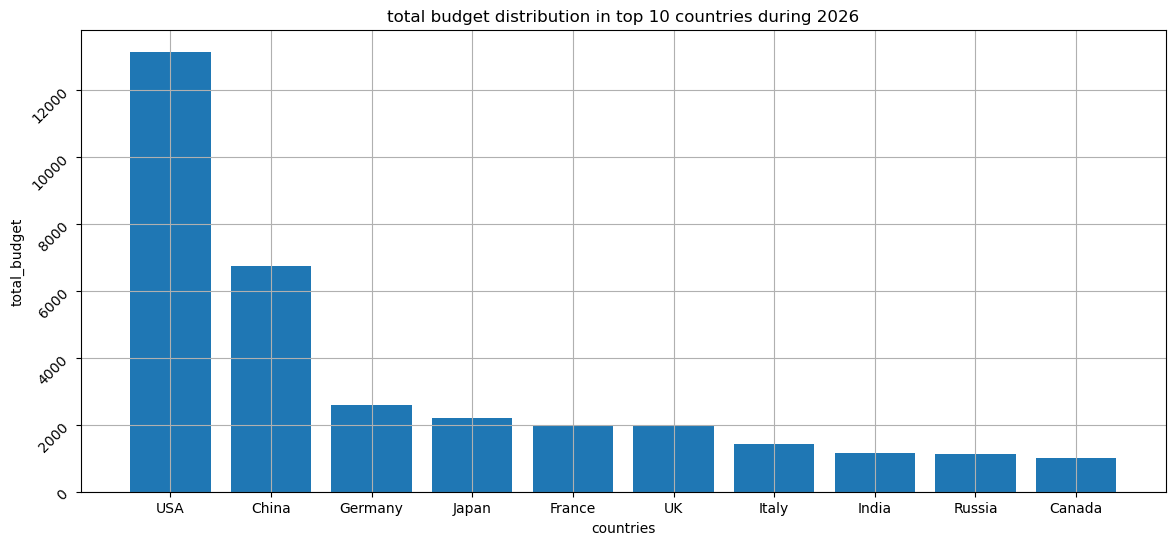

In [10]:
#comparing total budgets of all the countries in the year 2026

latest_yr = df['Year'].max()
latest_dt = df[df['Year'] == latest_yr]

top_10_countries = latest_dt.nlargest(10, 'Total_Budget_Billions_USD')

plt.figure(figsize=(14,6))
plt.bar(top_10_countries['Country'], top_10_countries['Total_Budget_Billions_USD'])
plt.title('total budget distribution in top 10 countries during 2026')
plt.xlabel('countries')
plt.ylabel('total_budget')
plt.grid()
plt.yticks(rotation=45)

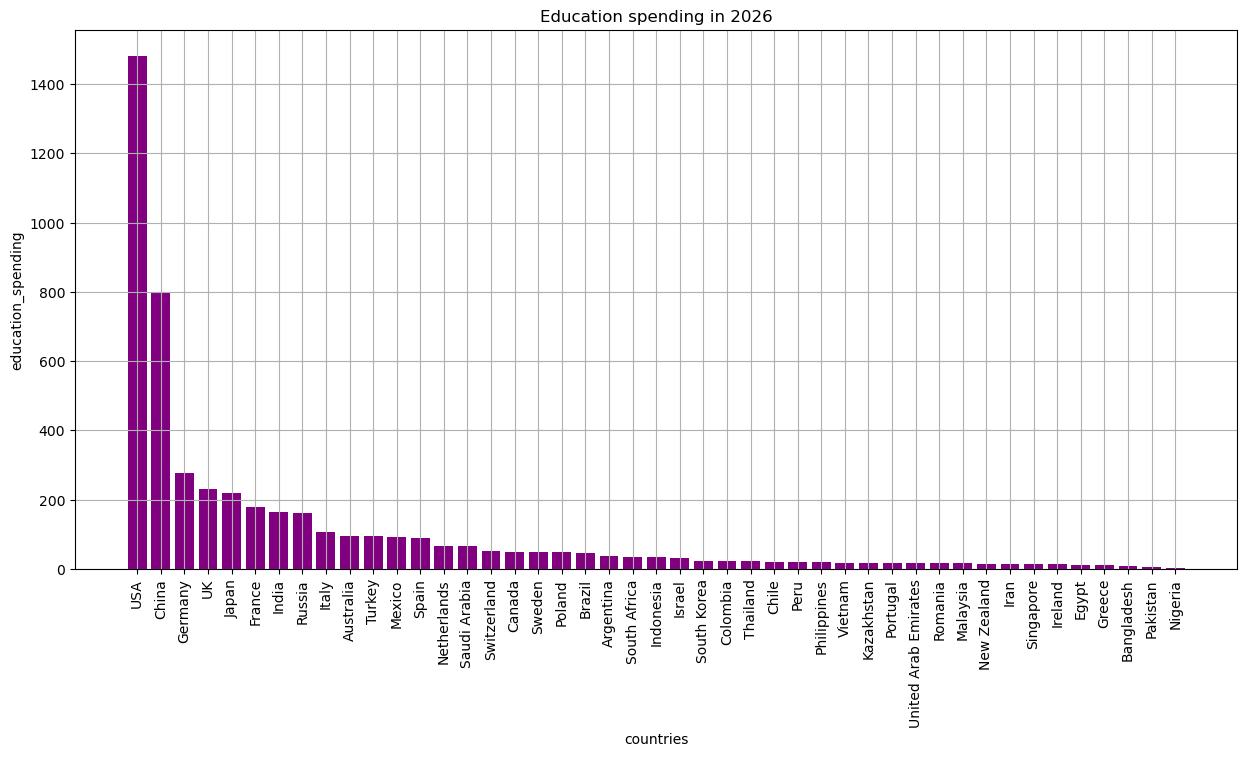

In [11]:
# comparing the spending distribution over education sector of top 10 countries

latest_yr = df['Year'].max()
latest_dt = df[df['Year'] == latest_yr]

latest_sorted = latest_dt.sort_values('Education_Amount_Billions_USD', ascending=False)

plt.figure(figsize=(15, 7))
plt.bar(latest_sorted['Country'], latest_sorted['Education_Amount_Billions_USD'], color='purple')
plt.title('Education spending in 2026')
plt.xlabel('countries')
plt.ylabel('education_spending')
plt.xticks(rotation=90)
plt.grid()

Text(0.5, 1.0, 'spending by category in 2026')

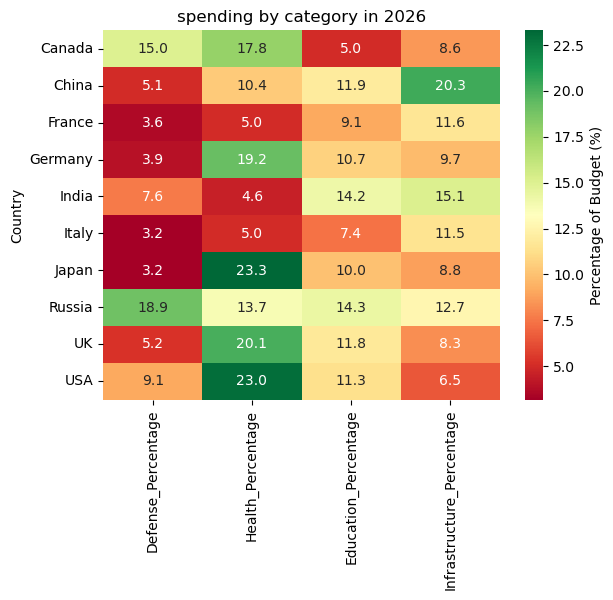

In [12]:
# analyising the spending patterns of certain countries

latest_yr = df['Year'].max()
latest_dt = df[df['Year'] == latest_yr]

top_10_budget = latest_dt.nlargest(10, 'Total_Budget_Billions_USD')
top_countries = top_10_budget['Country'].tolist()

latest_countries = df[df['Country'].isin(top_countries) & (df['Year']==latest_yr)]

categories = ['Defense_Percentage', 'Health_Percentage', 'Education_Percentage', 'Infrastructure_Percentage']


heatmap_data = latest_countries.set_index('Country')[categories]

sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn', 
            cbar_kws={'label': 'Percentage of Budget (%)'})

plt.title(f'spending by category in {latest_yr}', fontsize=12)


Text(0.5, 1.0, 'relation between infrastructure and defense percentage during 2008')

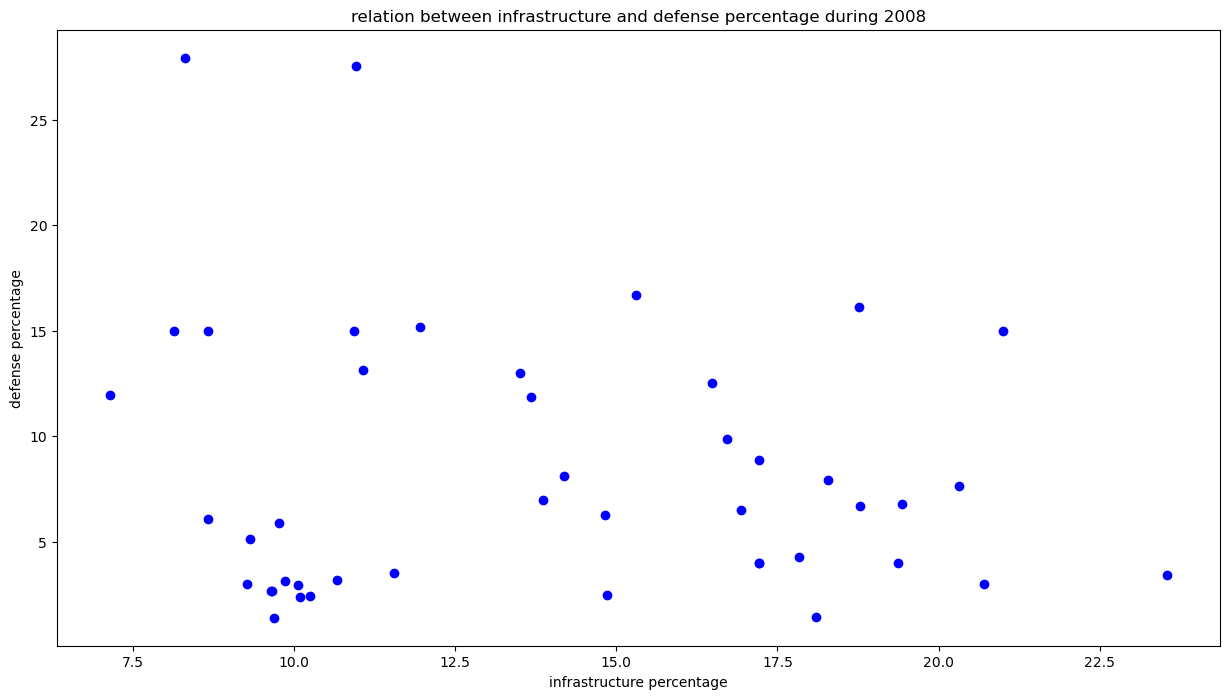

In [13]:
# visualizing patterns during 2008 crisis 

crisis_yr = 2008
crisis_dt = df[df['Year'] == crisis_yr]

x = crisis_dt['Infrastructure_Percentage']
y = crisis_dt['Defense_Percentage']

plt.figure(figsize=(15,8))
plt.scatter(x, y, color = 'blue')
plt.xlabel('infrastructure percentage')
plt.ylabel('defense percentage')
plt.title('relation between infrastructure and defense percentage during 2008')

Text(0, 0.5, 'defense_amt_bil')

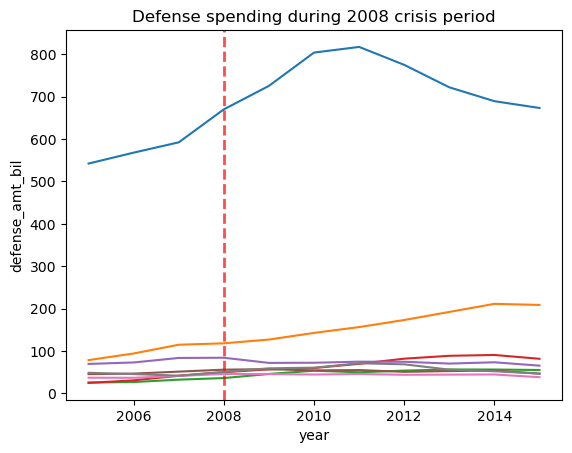

In [14]:
# defense spending during the 2008 crisis and percentage of budget


crisis_dt = df[(df['Year'] >= 2005) & (df['Year'] <= 2015)]

#major economies
maj_country = ['USA', 'China', 'India', 'Russia', 'UK', 'France', 'Germany', 'Japan']
for country in maj_country:
    country_dt = crisis_dt[crisis_dt['Country'] == country]
    plt.plot(country_dt['Year'], country_dt['Defense_Amount_Billions_USD'], label=country)

plt.axvline(x=2008, color='red', linestyle='--', linewidth=2, alpha=0.7, label='2008 financial crisis')
plt.title('Defense spending during 2008 crisis period')
plt.xlabel('year')
plt.ylabel('defense_amt_bil')




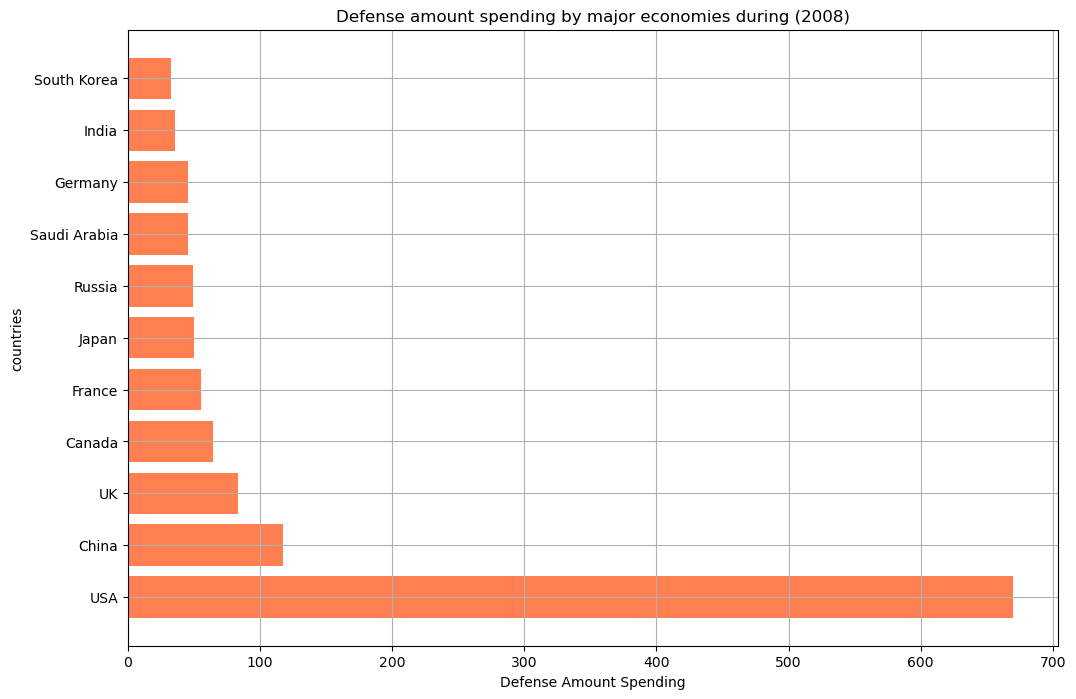

In [15]:
#defense spending during 2008

crisis_yr = 2008
crisis_dt = df[df['Year'] == crisis_yr]

#major economies
maj_country = ['USA', 'China', 'India', 'Russia', 'UK', 'France', 'Germany', 'Japan', 'Saudi Arabia', 'South Korea', 'Canada']

country_dt = crisis_dt[crisis_dt['Country'].isin(maj_country)]
country_dt = country_dt.sort_values('Defense_Amount_Billions_USD', ascending=False)

plt.figure(figsize=(12,8))
bars = plt.barh(country_dt['Country'], country_dt['Defense_Amount_Billions_USD'], color='coral')
plt.title(f'Defense amount spending by major economies during ({crisis_yr})')
plt.xlabel('Defense Amount Spending')
plt.ylabel('countries')
plt.grid()



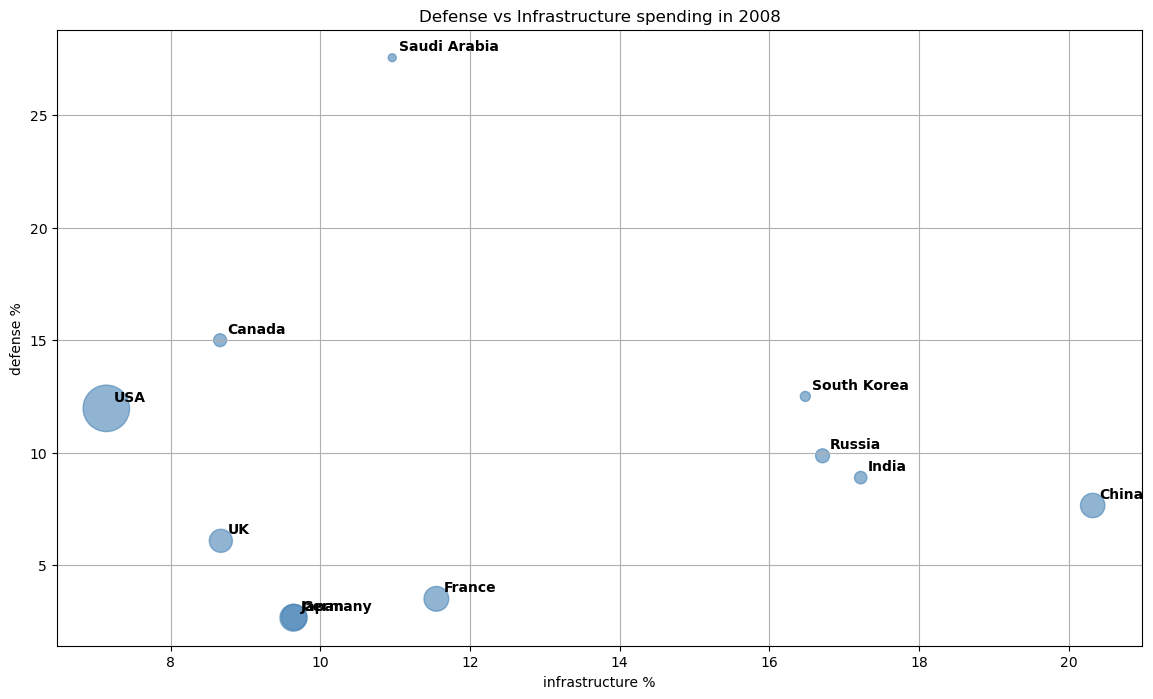

In [16]:
#defense spending vs infrastructure spending during 2008

crisis_yr = 2008
crisis_dt = df[df['Year'] == crisis_yr]

maj_countries = ['USA', 'China', 'India', 'Russia', 'UK', 'France', 'Germany', 'Japan', 'Saudi Arabia', 'South Korea', 'Canada']

country_dt = crisis_dt[crisis_dt['Country'].isin(maj_country)]
plt.figure(figsize = (14,8))

scatter = plt.scatter(country_dt['Infrastructure_Percentage'], country_dt['Defense_Percentage'], s = country_dt['Total_Budget_Billions_USD']/5,
                     alpha=0.6, c='steelblue')

for _, row in country_dt.iterrows():
    plt.annotate(row['Country'], (row['Infrastructure_Percentage'],row['Defense_Percentage']), fontsize=10, fontweight='bold', xytext=(5,5), 
                textcoords='offset points')




plt.title('Defense vs Infrastructure spending in 2008')
plt.xlabel('infrastructure %')
plt.ylabel('defense %')
plt.grid()

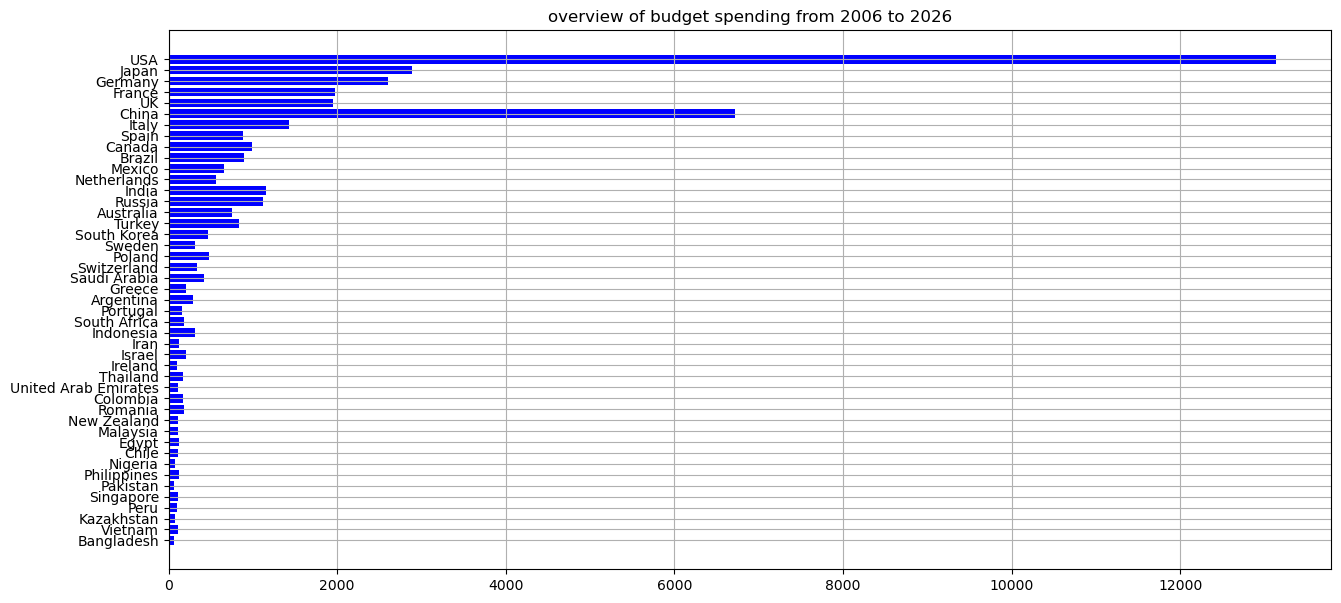

In [17]:
#fastest growing economy over the span of 20 years: from 2006 to 2026

ten_yr = df[(df['Year'] >= 2006) & (df['Year'] <= 2026)]
ten_yr_sorted = ten_yr.sort_values('Total_Budget_Billions_USD')

plt.figure(figsize=(15,7))
plt.barh(ten_yr_sorted['Country'], ten_yr_sorted['Total_Budget_Billions_USD'], color='blue')
plt.title('overview of budget spending from 2006 to 2026')
plt.grid()



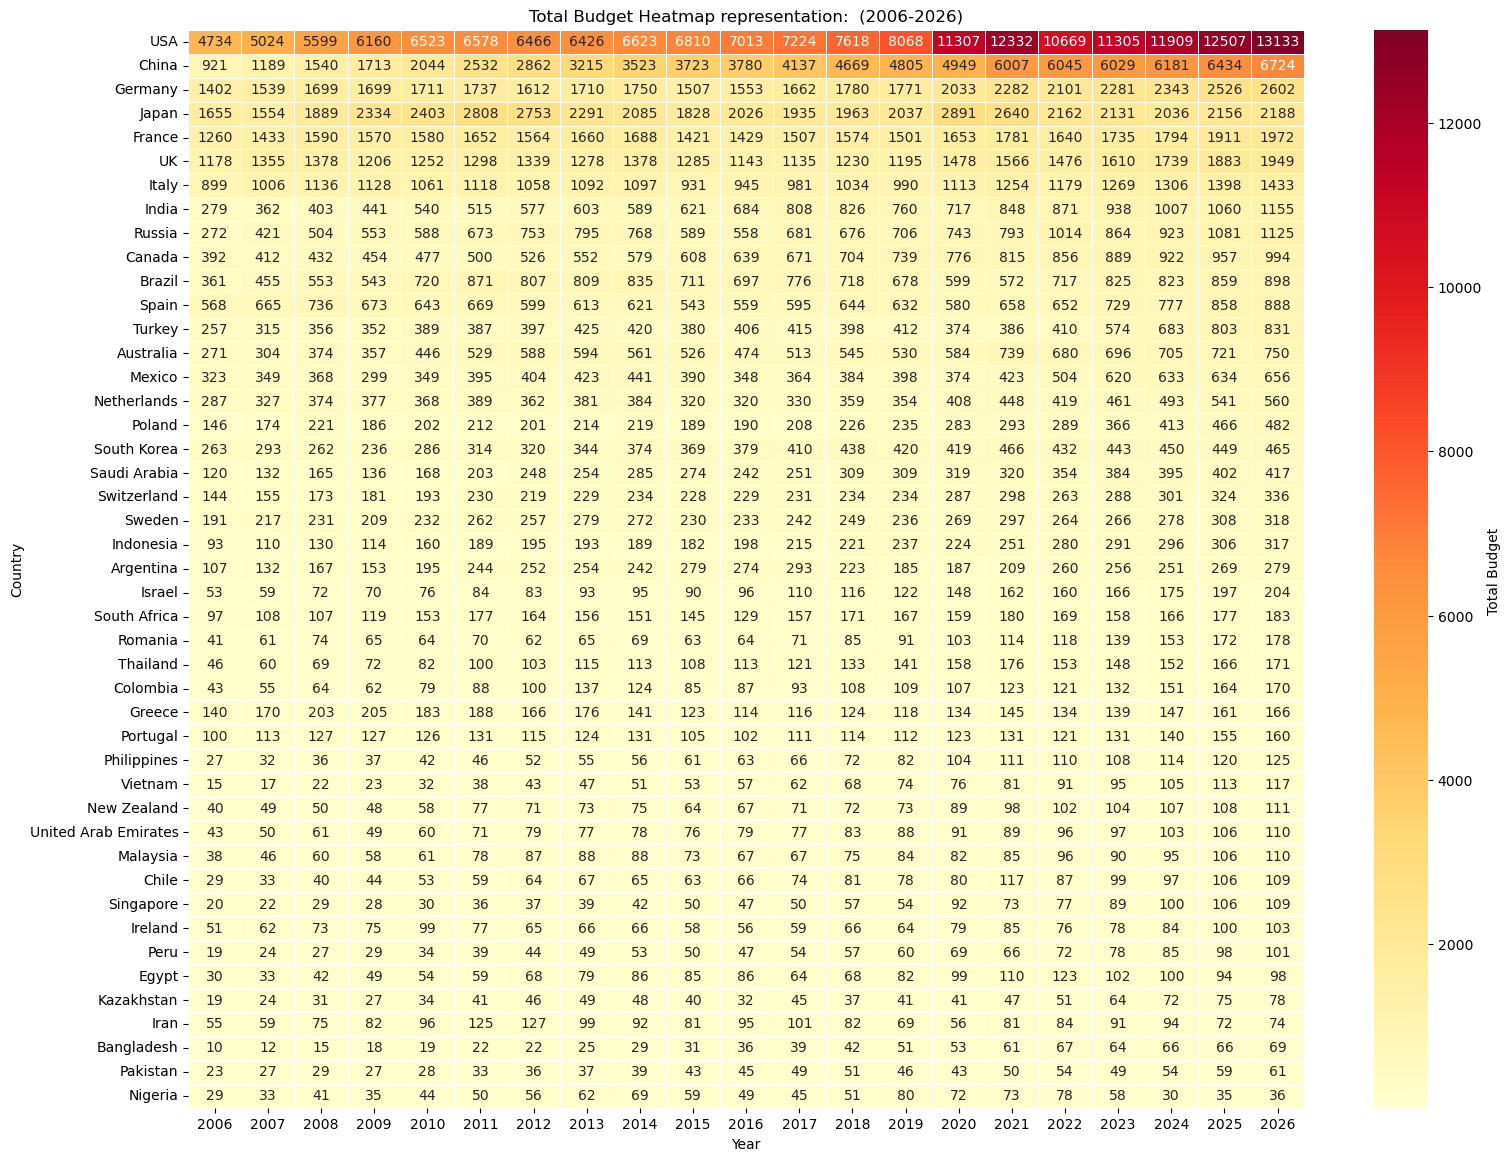

In [18]:
#heatmap representation of total budget spending over the span of 20 years leading upto 2026:

ten_yr = df[(df['Year'] >= 2006) & (df['Year'] <= 2026)]

heatmap_data = ten_yr.pivot(index='Country', columns='Year', values='Total_Budget_Billions_USD')
heatmap_data = heatmap_data.sort_values(heatmap_data.columns[-1], ascending=False)

plt.figure(figsize=(18,14))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.0f', cbar_kws={'label': 'Total Budget '}, linewidth=0.5, linecolor='white')
plt.title('Total Budget Heatmap representation:  (2006-2026)')
plt.xlabel('Year')
plt.ylabel('Country')
plt.show()


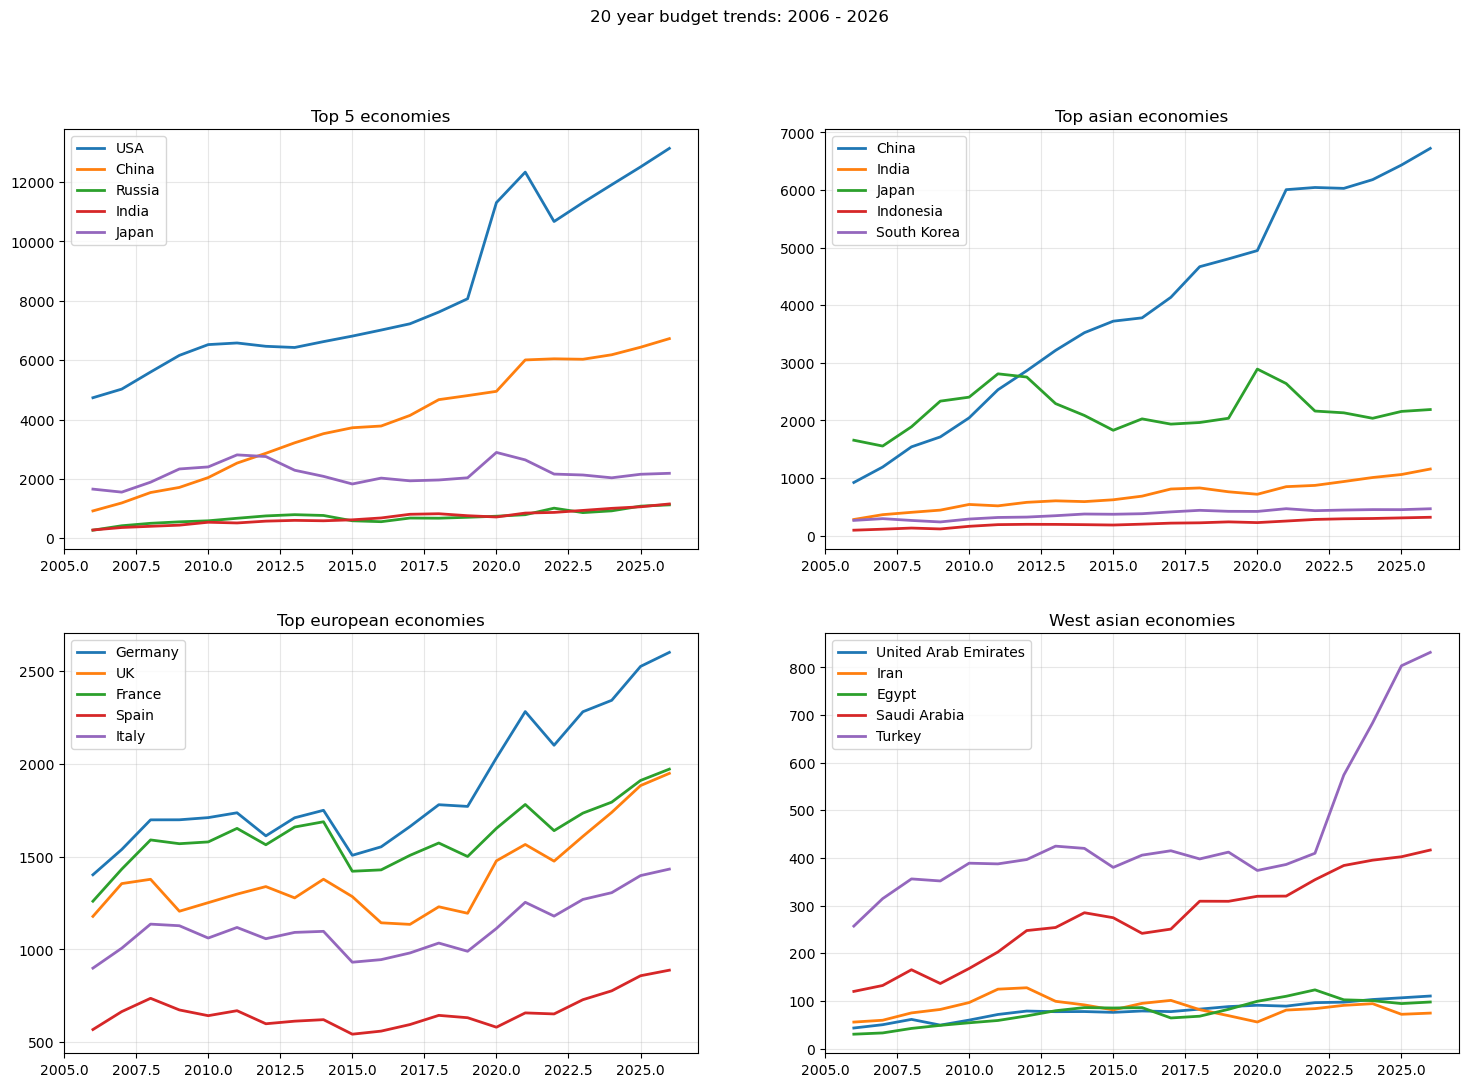

In [19]:
# visualization of budget growth among various country groups:

ten_yr = df[(df['Year'] >= 2006) & (df['Year'] <= 2026)]

fig, axes = plt.subplots(2,2,figsize=(18,12))
ax1 = axes[0,0]

#major economies:
maj_countries = ['USA', 'China', 'Russia', 'India','Japan']
for country in maj_countries:
    data = ten_yr[ten_yr['Country'] == country]
    ax1.plot(data['Year'], data['Total_Budget_Billions_USD'], label=country, linewidth=2)
ax1.set_title('Top 5 economies')
ax1.legend()
ax1.grid(True, alpha=0.3)

#asian countries:
ax2 = axes[0,1]
asian_countries = ['China','India','Japan','Indonesia', 'South Korea']
for country in asian_countries:
    data = ten_yr[ten_yr['Country'] == country]
    ax2.plot(data['Year'], data['Total_Budget_Billions_USD'], label=country, linewidth=2)
ax2.set_title('Top asian economies')
ax2.legend()
ax2.grid(True, alpha=0.3)

#european countries
ax3 = axes[1,0]
euro_countries = ['Germany', 'UK', 'France', 'Spain', 'Italy']
for country in euro_countries:
    data = ten_yr[ten_yr['Country'] == country]
    ax3.plot(data['Year'], data['Total_Budget_Billions_USD'], label=country, linewidth=2)
ax3.set_title('Top european economies')
ax3.legend()
ax3.grid(True, alpha=0.3)

# west asian countries

ax4 = axes[1,1]
westas_count = ['United Arab Emirates', 'Iran', 'Egypt', 'Saudi Arabia', 'Turkey']
for country in westas_count:
    data = ten_yr[ten_yr['Country'] == country]
    ax4.plot(data['Year'], data['Total_Budget_Billions_USD'], label=country, linewidth=2)
ax4.set_title('West asian economies')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle('20 year budget trends: 2006 - 2026')
plt.show()


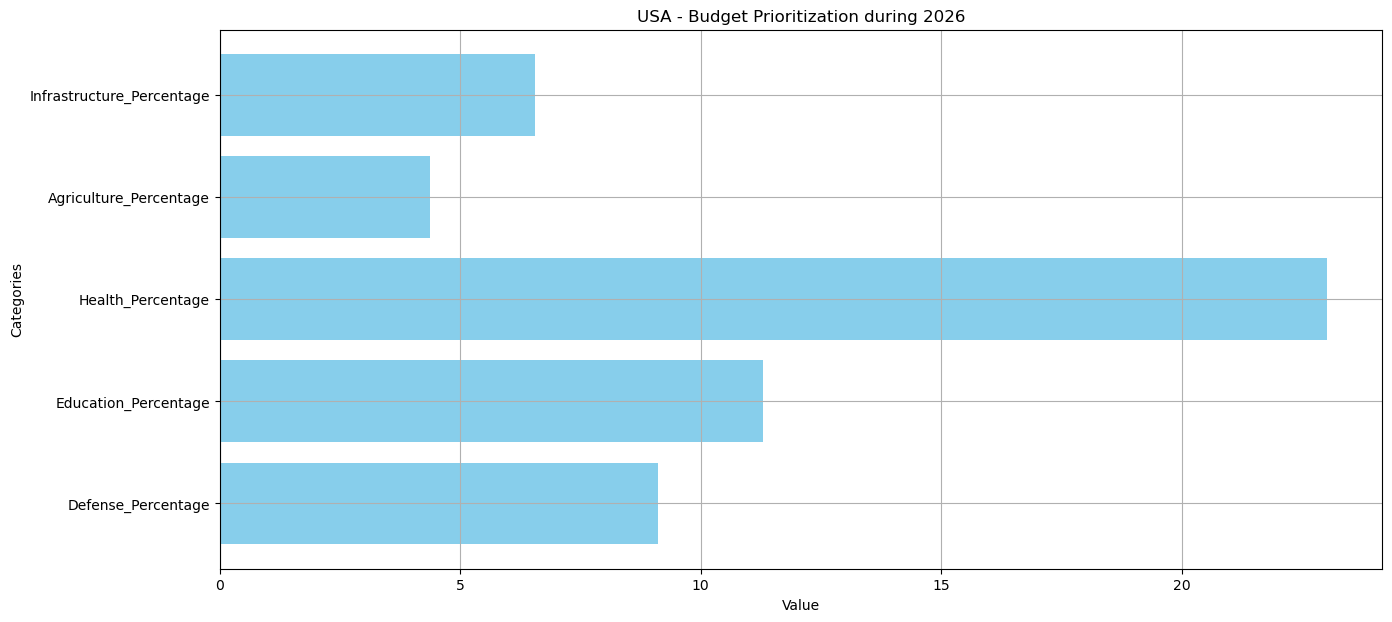

In [20]:
#budget prioritization in major economies: 1. USA:

USA_dt = df[(df['Year'] == 2026) & (df['Country'] == 'USA')]

categories = ['Defense_Percentage', 'Education_Percentage', 'Health_Percentage', 'Agriculture_Percentage', 'Infrastructure_Percentage']

#values = []
#for cat in categories:
    #if cat in USA_dt.columns:
     #   values.append(USA_dt[cat].iloc[0])
    #else:
     #   values.append(0)
        
plt.figure(figsize=(15,7))
#plt.barh(categories, values, color="orange")

for cat in categories:
    if cat in USA_dt.columns:
        val = USA_dt[cat].iloc[0]
        plt.barh(cat, val, color = "skyblue")

plt.title('USA - Budget Prioritization during 2026')
plt.ylabel('Categories')
plt.xlabel('Value')
plt.grid()
plt.show()

        
        


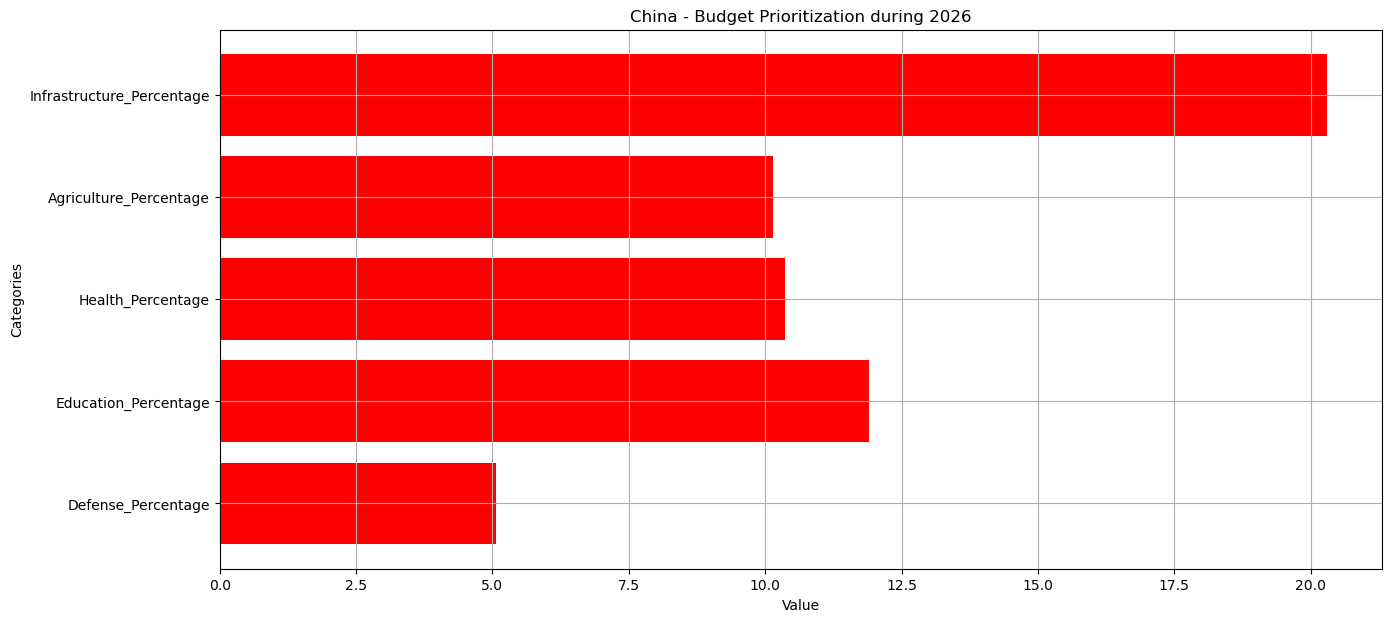

In [21]:
#2. China:

China_dt = df[(df['Year'] == 2026) & (df['Country'] == 'China')]
categories =  ['Defense_Percentage', 'Education_Percentage', 'Health_Percentage', 'Agriculture_Percentage', 'Infrastructure_Percentage']

plt.figure(figsize=(15,7))

for cat in categories:
    if cat in China_dt.columns:
        val = China_dt[cat].iloc[0]
        plt.barh(cat, val, color = "red")
        
plt.title('China - Budget Prioritization during 2026')
plt.ylabel('Categories')
plt.xlabel('Value')
plt.grid()
plt.show()


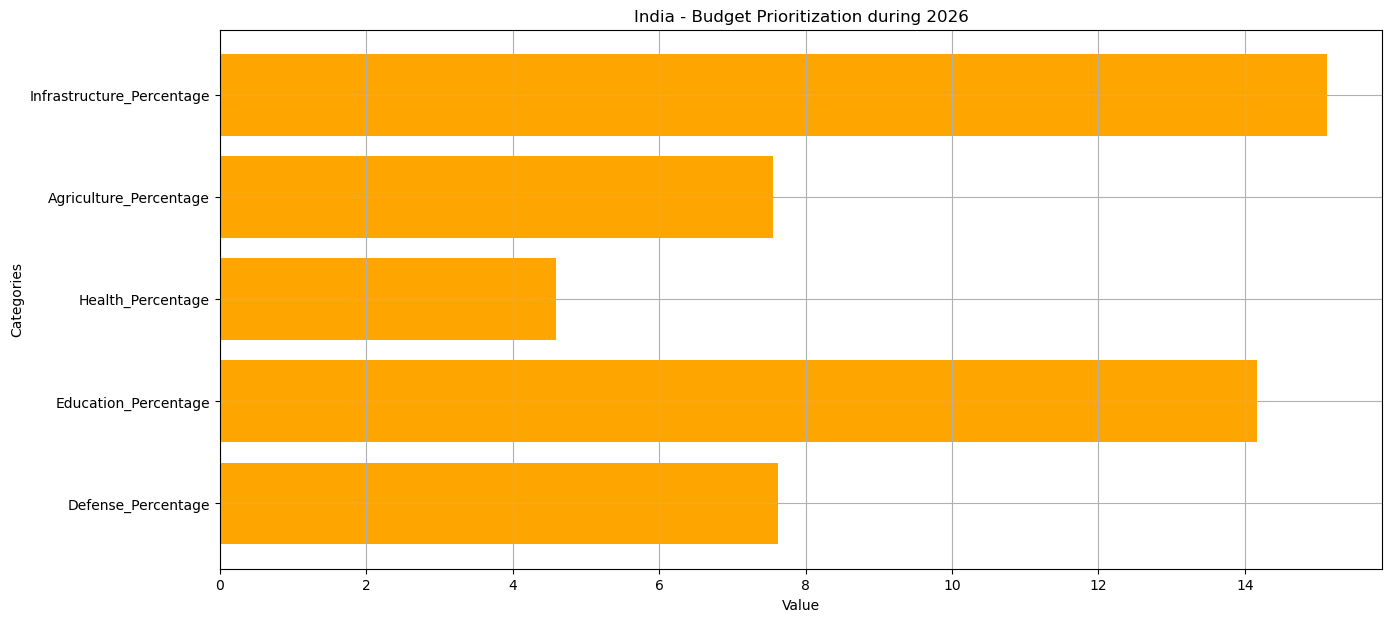

In [33]:
#3. India:

India_dt = df[(df['Year'] == 2026) & (df['Country'] == 'India')]
categories =  ['Defense_Percentage', 'Education_Percentage', 'Health_Percentage', 'Agriculture_Percentage', 'Infrastructure_Percentage']

plt.figure(figsize=(15,7))

for cat in categories:
    if cat in India_dt.columns:
        val = India_dt[cat].iloc[0]
        plt.barh(cat, val, color = "Orange")
        
plt.title('India - Budget Prioritization during 2026')
plt.ylabel('Categories')
plt.xlabel('Value')
plt.grid()
plt.show()

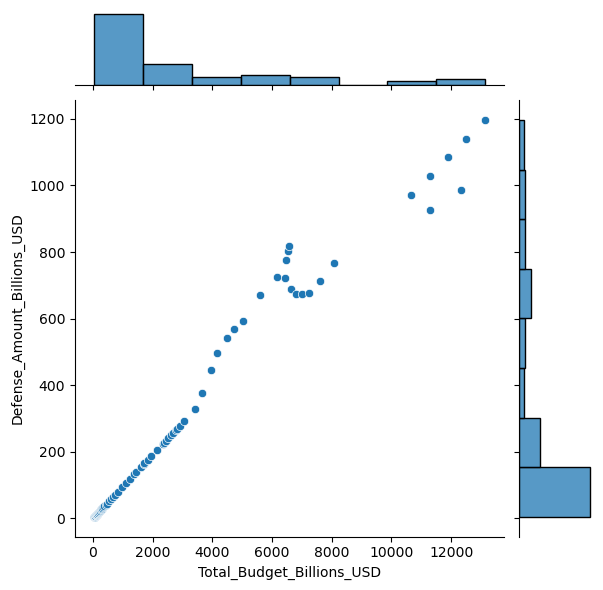

In [23]:
#correlation between variables total budget and defence spending over the span of 80 years
# 1.USA:

USA_dt = df[df['Country'] == 'USA']

plot = sns.jointplot(x = USA_dt['Total_Budget_Billions_USD'], y = USA_dt['Defense_Amount_Billions_USD'], data=USA_dt)


#conclusion: 
#this visualization shows that there is a strong positive correlatin between total budget and defense spending. Defense has always maintained to be
#approximately 8 - 10% of the total budget over the span of 80 years, as budget goes up, defense spending goes up as well. Defense is a fixed % of budget.


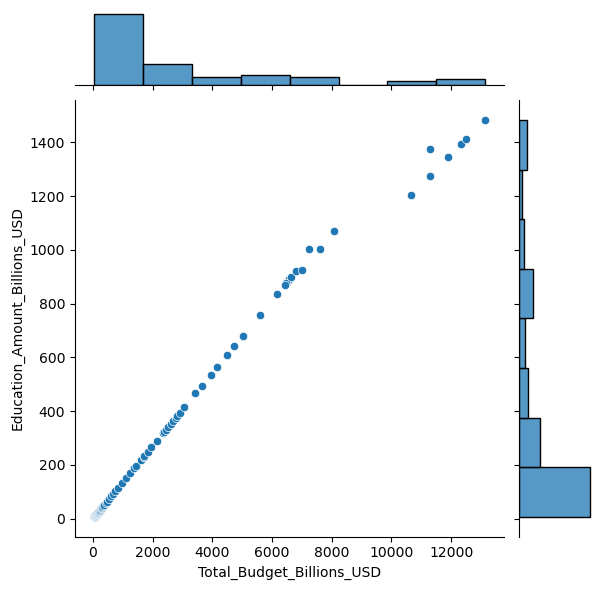

In [24]:
#inferring whether economic size determines investment in education over the span of years: 
USA_dt = df[df['Country'] == 'USA']

plot = sns.jointplot(x = USA_dt['Total_Budget_Billions_USD'], y = USA_dt['Education_Amount_Billions_USD'], data=USA_dt)


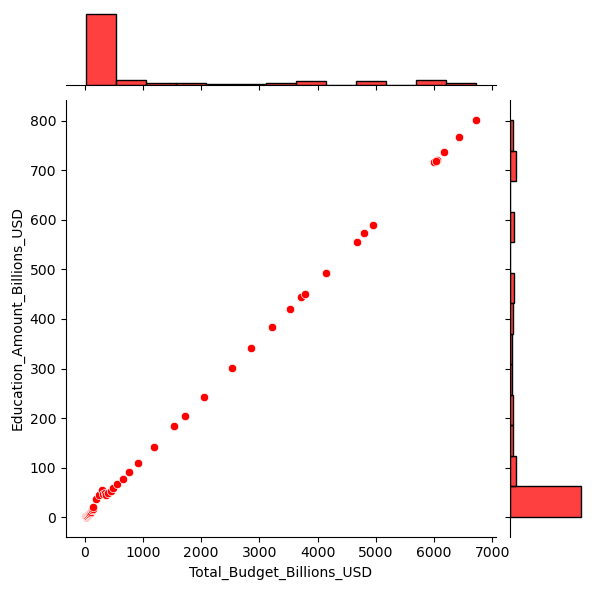

In [28]:
#2. China - correlation between the total budget and education investment over the span of 80 years:

China_dt = df[df['Country'] == 'China']
plot = sns.jointplot(x = China_dt['Total_Budget_Billions_USD'], y = China_dt['Education_Amount_Billions_USD'], data = China_dt, joint_kws={'color': 'red'}, marginal_kws={'color': 'red'})

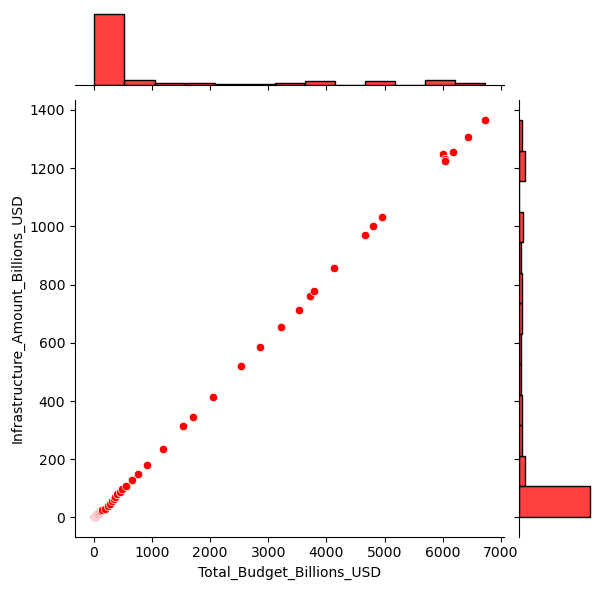

In [29]:
#infrastructure

China_dt = df[df['Country'] == 'China']
plot = sns.jointplot(x = China_dt['Total_Budget_Billions_USD'], y = China_dt['Infrastructure_Amount_Billions_USD'], data = China_dt, joint_kws={'color': 'red'}, marginal_kws={'color': 'red'})

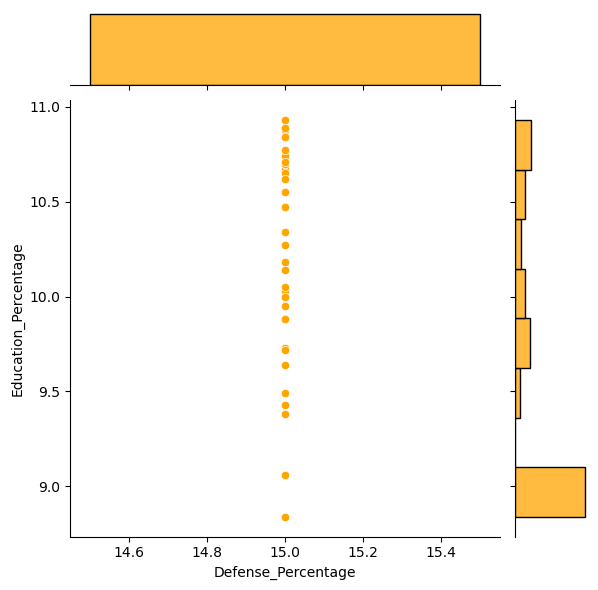

In [31]:
#checking for trade off relationships between variables such as defence and education in various countries: 
#1. Spain:

Spain_dt = df[df['Country'] == 'Spain']
plot = sns.jointplot(x = Spain_dt['Defense_Percentage'], y = Spain_dt['Education_Percentage'], data = Spain_dt, joint_kws={'color': 'orange'}, marginal_kws={'color': 'orange'})


#Spain has fixed defense budget whereas education spending was more flexible from 9 - 11 %:
#this shows Spain has not traded military for education
#and shows rising spending in education whereas has maintained a stable defense showcasing long term security commitment.
#balanced approach

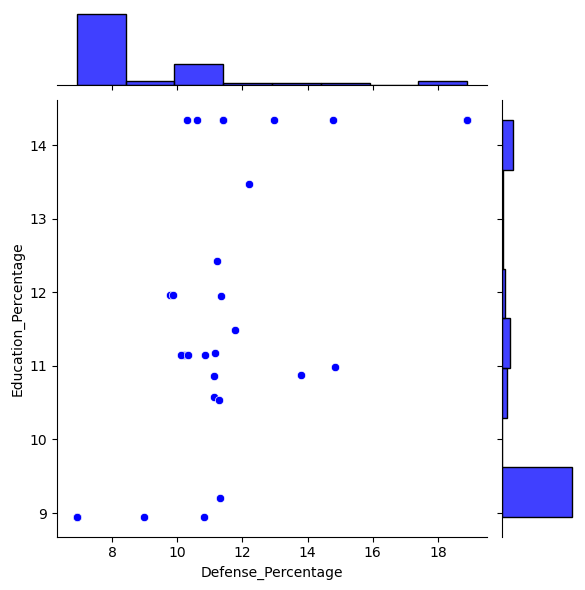

In [33]:
#2. Russia: 

Russia_dt = df[df['Country'] == 'Russia']
plot = sns.jointplot(x = Russia_dt['Defense_Percentage'], y = Russia_dt['Education_Percentage'], data = Russia_dt, joint_kws={'color': 'blue'}, marginal_kws={'color': 'blue'})

#This diagram show that Russia's defense is highly volatile and is dependent upon geoplitcs:

#Russia's defense:
#low point - post soviet era, 1990s
#high point - soviet era, 1940s 
#recent : 15 - 20% during ukraine invasion
# as defense spending goes UP, education investment goes DOWN
#negative correlation detected!